In [1]:
import os

os.environ["SCIPY_ARRAY_API"] = "1"

import pandas as pd
import numpy as np
import seaborn as sns

from dpks import QuantMatrix



In [2]:
clinical_columns = [
    "sao2_ambulance",
    "resp_frequency_ambulance",
    "heart_rate_ambulance",
    "syst_bp_ambulance",
    "map_ambulance",
    "mental_status_ambulance", # categorical
    "temperature_ambulance",
    "crea_emergency_department",
    "bili_emergency_department",
    "crp_day1",
    "trc_emergency_department",
    "sex",
    "age"
]

continuous_clinical_columns = [
    "sao2_ambulance",
    "resp_frequency_ambulance",
    "heart_rate_ambulance",
    "syst_bp_ambulance",
    "map_ambulance",
    "temperature_ambulance",
    "crea_emergency_department",
    "bili_emergency_department",
    "trc_emergency_department",
    "crp_day1",
    "age"
]

categorical_clinical_columns = [
    "mental_status_ambulance",
]

selected_features = [
    'VWF_HUMAN',
    'CRP_HUMAN',
    'AACT_HUMAN',
    'B2MG_HUMAN',
    'IBP3_HUMAN',
    'FIBG_HUMAN',
    'CYTC_HUMAN',
    'VCAM1_HUMAN',
    'LBP_HUMAN',
    'A2GL_HUMAN'
]

In [3]:
continuous_clinical_columns.extend(selected_features)

In [4]:

def preprocess_design_matrix(design_matrix):

    # design_matrix = design_matrix[
    #     ((design_matrix['Sepsis Diagnosis Probability'] >= 0.8) | 
    #     (design_matrix['Sepsis Diagnosis Probability'] <= 0.50))
    # ].copy()

    design_matrix['group'] = 1

    design_matrix['sample'] = design_matrix['injection']

    return design_matrix

In [5]:
def preprocess_data(raw_data, design_matrix):

    quant_matrix = QuantMatrix(
        quantification_file=raw_data[['Protein'] + [sample for sample in design_matrix['sample'].values]].copy(),
        design_matrix_file=design_matrix,
        annotation_fasta_file="../0_data/2023-04-24-UP000005640.fas"
    )

    quant_data = quant_matrix.to_df()
    
    quant_data = quant_data[~((quant_data["ProteinLabel"].str.startswith("HV")) | (quant_data["ProteinLabel"].str.startswith("LV")) | quant_data["ProteinLabel"].str.startswith("KV"))]
    quant_data = quant_data[~quant_data["ProteinLabel"].str.startswith("IG")]
    quant_data = quant_data[~((quant_data["ProteinLabel"] == "HBA_HUMAN") | (quant_data["ProteinLabel"] == "HBB_HUMAN") | (quant_data["ProteinLabel"] == "HBD_HUMAN") | (quant_data["ProteinLabel"] == "HEMO_HUMAN"))]

    quant_matrix = QuantMatrix(
        quantification_file=quant_data,
        design_matrix_file=design_matrix,
        annotation_fasta_file="../0_data/2023-04-24-UP000005640.fas"
    )

    return quant_matrix.annotate()     


In [6]:
ms_data = pd.read_csv(
    "../0_data/proteins_test_filtered.tsv"
    , sep="\t"
)

In [7]:
design_matrix = pd.read_csv(
    "../0_data/design_matrix_test.tsv",
    sep='\t'
)

In [8]:
ms_data_test = pd.read_csv(
    "../0_data/proteins_val_filtered.tsv"
    , sep="\t"
)
design_matrix_test = pd.read_csv(
    "../0_data/design_matrix_validation.tsv",
    sep='\t'
)

In [9]:
design_matrix['survival_30_day'] = np.where(design_matrix['survival_days'] <= 30, 1, 0)
design_matrix_test['survival_30_day'] = np.where(design_matrix_test['survival_days'] <= 30, 1, 0)


design_matrix['future_deterioration'] = np.where(
    design_matrix['sofa_score_increase_day2'] > 1, 1, np.where(
        design_matrix['sofa_score_increase_day3'] > 1, 1, 0
    )
)

design_matrix_test['future_deterioration'] = np.where(
    design_matrix_test['sofa_score_increase_day2'] > 1, 1, np.where(
        design_matrix_test['sofa_score_increase_day3'] > 1, 1, 0
    )
)

In [10]:
design_matrix_train = preprocess_design_matrix(design_matrix)

quant_matrix_train = preprocess_data(ms_data, design_matrix=design_matrix_train)

In [11]:
quant_matrix_train_df = quant_matrix_train.to_df()
quant_matrix_train_df = quant_matrix_train_df[quant_matrix_train_df['ProteinLabel'].isin(selected_features)]

In [12]:
qm_filtered_train = (

    QuantMatrix(
        quantification_file=quant_matrix_train_df,
        design_matrix_file=design_matrix_train
    )

)

In [13]:
training_data, y = qm_filtered_train.to_ml(feature_column="ProteinLabel")

In [14]:
training_data = training_data.join(
    design_matrix_train.set_index("injection")
)

In [15]:
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.impute import SimpleImputer


In [16]:
design_matrix_test = preprocess_design_matrix(design_matrix_test)

quant_matrix_test = preprocess_data(ms_data_test, design_matrix=design_matrix_test)

In [17]:
quant_matrix_test_df = quant_matrix_test.to_df()
quant_matrix_test_df = quant_matrix_test_df[quant_matrix_test_df['ProteinLabel'].isin(selected_features)]

In [18]:
qm_filtered_test = (
    
    QuantMatrix(
        quantification_file=quant_matrix_test_df,
        design_matrix_file=design_matrix_test
    )
    
)

In [19]:
testing_data, y_test = qm_filtered_test.to_ml(feature_column="ProteinLabel")

In [20]:
testing_data = testing_data.join(
    design_matrix_test.set_index("injection")
)

In [21]:
from sklearn.preprocessing import StandardScaler, LabelBinarizer, MinMaxScaler
from sklearn.impute import SimpleImputer

clinical_scaler = StandardScaler()
protein_scaler = StandardScaler()

clinical_imputer = SimpleImputer()
sex_scaler = MinMaxScaler((0, 1))
constant_imputer = SimpleImputer(strategy="constant", fill_value=1.0)

training_data[continuous_clinical_columns] = clinical_imputer.fit_transform(training_data[continuous_clinical_columns])
training_data[["mental_status_ambulance"]] = constant_imputer.fit_transform(training_data[["mental_status_ambulance"]])

training_data[continuous_clinical_columns] = clinical_scaler.fit_transform(training_data[continuous_clinical_columns])
training_data[['sex']] = sex_scaler.fit_transform(training_data[['sex']])

testing_data[continuous_clinical_columns] = clinical_imputer.transform(testing_data[continuous_clinical_columns])
testing_data[["mental_status_ambulance"]] = constant_imputer.transform(testing_data[["mental_status_ambulance"]])

testing_data[continuous_clinical_columns] = clinical_scaler.transform(testing_data[continuous_clinical_columns])
testing_data[['sex']] = sex_scaler.transform(testing_data[['sex']])


In [22]:
training_data = training_data.reset_index(drop=True)

In [23]:
testing_data = testing_data.reset_index(drop=True)

In [27]:
combined_features = clinical_columns + selected_features
combined_features

['sao2_ambulance',
 'resp_frequency_ambulance',
 'heart_rate_ambulance',
 'syst_bp_ambulance',
 'map_ambulance',
 'mental_status_ambulance',
 'temperature_ambulance',
 'crea_emergency_department',
 'bili_emergency_department',
 'crp_day1',
 'trc_emergency_department',
 'sex',
 'age',
 'VWF_HUMAN',
 'CRP_HUMAN',
 'AACT_HUMAN',
 'B2MG_HUMAN',
 'IBP3_HUMAN',
 'FIBG_HUMAN',
 'CYTC_HUMAN',
 'VCAM1_HUMAN',
 'LBP_HUMAN',
 'A2GL_HUMAN']

In [33]:
from dfmodel import DigitalFamilyBinary

df_estimator = DigitalFamilyBinary(
    n_neighbors=5,
    neighbor_metric="euclidean",
    bootstrap_iterations=1000,
)

df_estimator.fit(training_data, features=combined_features)

In [34]:
training_data['Sepsis Rates'] = df_estimator.predict(training_data, features=combined_features, target_column="sepsis_or_septic_shock", bootstrap=False)
training_data['Infection Rates'] = df_estimator.predict(training_data, features=combined_features, target_column="verified_infection", bootstrap=False)
training_data['Future Organ Dysfunction'] = df_estimator.predict(training_data, features=combined_features, target_column="future_deterioration", bootstrap=False)
training_data['30 Day Mortality'] = df_estimator.predict(training_data, features=combined_features, target_column="survival_30_day", bootstrap=False)

In [35]:
from fa2_modified import ForceAtlas2
import matplotlib.pyplot as plt
import networkx as nx

G = df_estimator.network_

positions = nx.forceatlas2_layout(
    G,
    max_iter=1000,
    seed=0,
    #strong_gravity=True,
    dissuade_hubs=True
)

In [36]:
display_columns = [
    "Sepsis Rates",
    "Infection Rates",
    "Future Organ Dysfunction",
    "30 Day Mortality",
]

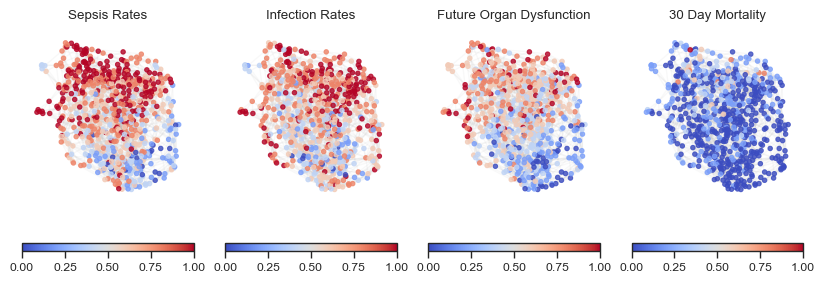

In [38]:
import matplotlib.pyplot as plt
sns.set_theme(font="Arial", style="white", context="paper")


fig, axs = plt.subplots(
    nrows=1,
    ncols=4
)

for i, col in enumerate(display_columns):

    # values = training_data[col].to_numpy()
    # cmap = plt.cm.coolwarm
    # norm = plt.Normalize(vmin=training_data[col].min(), vmax=training_data[col].max())
    # colors = cmap(norm(values))

    color_normalizer = MinMaxScaler((0, 1))

    values = MinMaxScaler().fit_transform(training_data[[col]])

    color_map = dict(zip(training_data.index, values))
    node_colors = [color_map[node] for node in G.nodes()]

    nx.draw_networkx_nodes(G, positions, node_size=10, node_color=node_colors, cmap="coolwarm", alpha=0.8, ax=axs[i])
    nx.draw_networkx_edges(G, positions, edge_color="gray", alpha=0.05, ax=axs[i])

    axs[i].axis("off")

    axs[i].set_title(col)

    sm = plt.cm.ScalarMappable(cmap="coolwarm")
    cbar = fig.colorbar(sm, ax=axs[i], orientation="horizontal")

    #cbar = fig.colorbar(ax=axs[i])

fig.set_size_inches((8.27, 3))
plt.tight_layout()

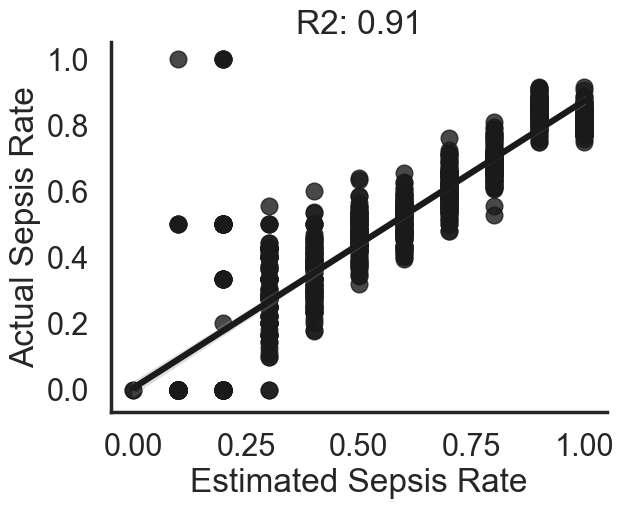

In [71]:
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt


X_test_results = pd.concat([X_test.reset_index(),  df_estimator.bootstrap_results_df], axis=1)

fig, ax = plt.subplots()

protein_estimated_sepsis, protein_linregress_results, protein_predictions, protein_corr, protein_pval = plot_results(X_test_results, df_estimator.bootstrap_results_df)


sns.regplot(
    data=protein_estimated_sepsis,
    x="Estimated Sepsis Rate",
    y="Actual Sepsis Rate",
    ax=ax,
    color="k"
)

ax.set_title(
    f"R2: {protein_linregress_results.rvalue:.2f}"
)

sns.despine()

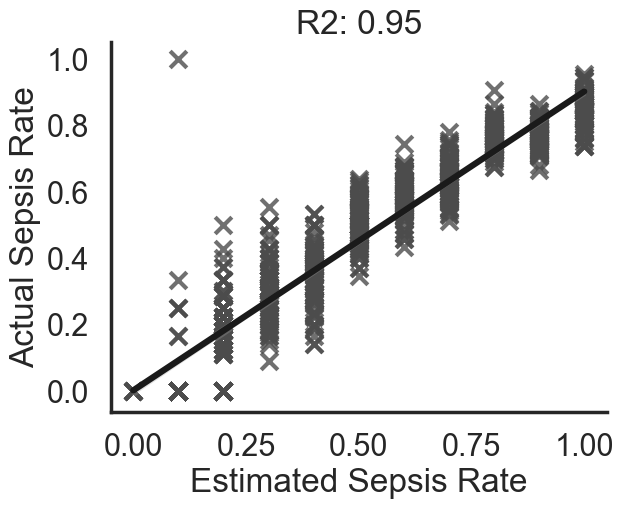

In [72]:
df_estimator = DigitalFamilyBinary()

df_estimator.fit(X_subset, features=clinical_columns)
X_test['Sepsis Protein Prob'] = df_estimator.predict(
    X_test[clinical_columns], 
    features=clinical_columns, 
    target_column="sepsis_or_septic_shock"
)


X_test_results = pd.concat([X_test.reset_index(),  df_estimator.bootstrap_results_df], axis=1)

fig, ax = plt.subplots()

clinical_estimated_sepsis, clinical_linregress_results, clinical_predictions, clinical_corr, clinical_pval = plot_results(X_test_results, df_estimator.bootstrap_results_df)


sns.regplot(
    data=clinical_estimated_sepsis,
    x="Estimated Sepsis Rate",
    y="Actual Sepsis Rate",
    ax=ax,
    color=".3",
    marker="x",
    line_kws=dict(color="k")
)

ax.set_title(
    f"R2: {clinical_linregress_results.rvalue:.2f}"
)

sns.despine()

In [73]:
clinical_columns.extend(selected_features)
clinical_columns

['sao2_ambulance',
 'resp_frequency_ambulance',
 'heart_rate_ambulance',
 'syst_bp_ambulance',
 'map_ambulance',
 'mental_status_ambulance',
 'temperature_ambulance',
 'crea_emergency_department',
 'bili_emergency_department',
 'crp_day1',
 'trc_emergency_department',
 'sex',
 'age',
 'VWF_HUMAN',
 'CRP_HUMAN',
 'AACT_HUMAN',
 'B2MG_HUMAN',
 'IBP3_HUMAN',
 'FIBG_HUMAN',
 'CYTC_HUMAN',
 'VCAM1_HUMAN',
 'LBP_HUMAN',
 'A2GL_HUMAN']

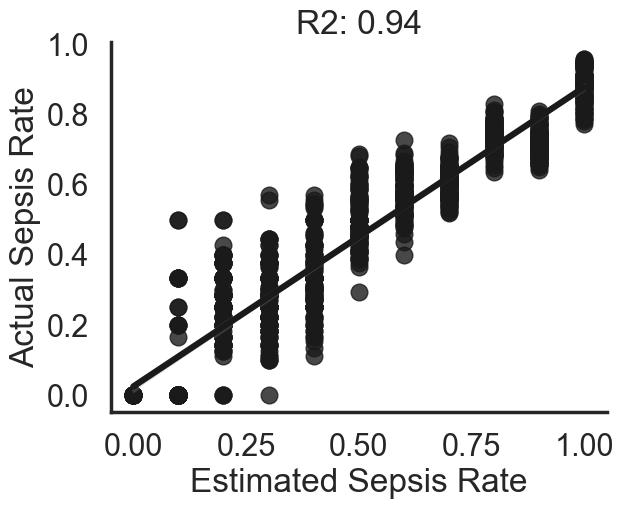

In [74]:
df_estimator = DigitalFamilyBinary()

df_estimator.fit(X_subset, features=clinical_columns)
X_test['Sepsis Protein Prob'] = df_estimator.predict(
    X_test[clinical_columns], 
    features=clinical_columns, 
    target_column="sepsis_or_septic_shock"
)

X_test_results = pd.concat([X_test.reset_index(),  df_estimator.bootstrap_results_df], axis=1)

fig, ax = plt.subplots()

combined_estimated_sepsis, combined_linregress_results, combined_predictions, combined_corr, combined_pval = plot_results(X_test_results, df_estimator.bootstrap_results_df)

sns.regplot(
    data=combined_estimated_sepsis,
    x="Estimated Sepsis Rate",
    y="Actual Sepsis Rate",
    ax=ax,
    color="k"
)

ax.set_title(
    f"R2: {combined_linregress_results.rvalue:.2f}"
)

sns.despine()

In [75]:
combined_estimated_sepsis

,Actual Sepsis Rate,Estimated Sepsis Rate,Counts
0,0.000000,0.1,2
1,0.200000,0.2,10
2,0.400000,0.3,10
3,0.333333,0.4,12
4,0.478261,0.5,23
...,...,...,...
5,0.659091,0.6,44
6,0.560000,0.7,50
7,0.745763,0.8,59
8,0.742857,0.9,35


In [76]:
protein_estimated_sepsis['Label'] = "Protein"
clinical_estimated_sepsis['Label'] = "Clinical"
combined_estimated_sepsis['Label'] = "Combined"

In [77]:
protein_estimated_sepsis['Predictions'] = protein_predictions
clinical_estimated_sepsis['Predictions'] = clinical_predictions
combined_estimated_sepsis['Predictions'] = combined_predictions
combined_estimated_sepsis

,Actual Sepsis Rate,Estimated Sepsis Rate,Counts,Label,Predictions
0,0.000000,0.1,2,Combined,0.109534
1,0.200000,0.2,10,Combined,0.194914
2,0.400000,0.3,10,Combined,0.280294
3,0.333333,0.4,12,Combined,0.365674
4,0.478261,0.5,23,Combined,0.451055
...,...,...,...,...,...
5,0.659091,0.6,44,Combined,0.536435
6,0.560000,0.7,50,Combined,0.621815
7,0.745763,0.8,59,Combined,0.707196
8,0.742857,0.9,35,Combined,0.792576


In [78]:
# protein_estimated_s = protein_estimated_sepsis[['Estimated Sepsis Rate', 'Actual Sepsis Rate', 'Predictions']].groupby('Estimated Sepsis Rate').mean().reset_index()
# protein_estimated_s['Label'] = "Protein"

In [79]:
# clinical_estimated_s = clinical_estimated_sepsis[['Estimated Sepsis Rate', 'Actual Sepsis Rate', 'Predictions']].groupby('Estimated Sepsis Rate').mean().reset_index()
# clinical_estimated_s['Label'] = "Clinical"

In [80]:
# combined_estimated_s = combined_estimated_sepsis[['Estimated Sepsis Rate', 'Actual Sepsis Rate', 'Predictions']].groupby('Estimated Sepsis Rate').mean().reset_index()
# combined_estimated_s['Label'] = "Combined"

In [81]:
estimated_sepsis = pd.concat(
    [
        protein_estimated_sepsis,
        clinical_estimated_sepsis,
        combined_estimated_sepsis
    ]
)
estimated_sepsis

,Actual Sepsis Rate,Estimated Sepsis Rate,Counts,Label,Predictions
0,0.000000,0.1,1,Protein,0.091713
1,0.272727,0.3,11,Protein,0.265465
2,0.333333,0.4,21,Protein,0.352341
3,0.633333,0.5,30,Protein,0.439217
4,0.421053,0.6,38,Protein,0.526094
...,...,...,...,...,...
5,0.659091,0.6,44,Combined,0.536435
6,0.560000,0.7,50,Combined,0.621815
7,0.745763,0.8,59,Combined,0.707196
8,0.742857,0.9,35,Combined,0.792576


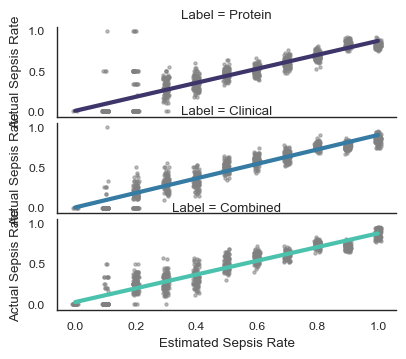

In [82]:
#fig, ax = plt.subplots()

sns.set_theme(context="paper", style="white")

g = sns.lmplot(
    data=estimated_sepsis,
    x="Estimated Sepsis Rate",
    y="Actual Sepsis Rate",
    hue="Label",
    row="Label",
    ci=95,
    palette="mako",
    scatter_kws={"color": "gray", "alpha": 0.5, "s": 5},
    line_kws={"lw": "3"},
    #scatter_kws={'alpha': 0.1, 's': 5},
    scatter=True,
    x_ci=95,
    x_jitter=0.01,
    #s=100,
    #ax=ax
)

# sns.lineplot(
#     data=estimated_sepsis,
#     x='Estimated Sepsis Rate',
#     y="Predictions",
#     hue="Label",
#     palette="mako",
#     lw=2,
#     ax=ax
# )

#g.axes[0].axline((0, 0), slope=1, color='k', linestyle='--')

sns.despine()

# ax.set_title(
#     f"R2: {combined_linregress_results.rvalue:.2f}\n
#     "
# )

g.figure.set_size_inches((4, 3))


In [83]:
g.figure.savefig(
    "digital_family_sepsis.pdf", dpi=300, bbox_inches="tight"
)

In [84]:
estimated_sepsis.to_csv(
    "digital_family_sepsis.tsv",
    sep="\t",
    index=False
)